<a href="https://colab.research.google.com/github/RAseng77/AIFFEL_QUEST_RS/blob/master/Exploration/Ex07/Exploration_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import urllib.request
import sentencepiece as spm
import numpy as np

# 1. 네이버 영화 리뷰 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt")
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt")

train_data = pd.read_table('ratings_train.txt')
test_data = pd.read_table('ratings_test.txt')

# 2. 데이터 전처리 (Null 제거 및 한글/공백만 남기기)
# 학습 데이터
train_data.drop_duplicates(subset=['document'], inplace=True)
train_data = train_data.dropna(how = 'any')
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
train_data['document'] = train_data['document'].str.strip()
train_data = train_data.loc[train_data.document != ""] # 공백만 남은 데이터 제거

# 테스트 데이터
test_data.drop_duplicates(subset=['document'], inplace=True)
test_data = test_data.dropna(how = 'any')
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
test_data['document'] = test_data['document'].str.strip()
test_data = test_data.loc[test_data.document != ""]

print(f"학습 데이터 개수: {len(train_data)}")
print(f"테스트 데이터 개수: {len(test_data)}")

# 3. SentencePiece 학습을 위해 텍스트 파일로 저장 ('utf-8' 주의!)
with open('nsmc_corpus.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_data['document']))

# 4. SentencePiece 모델 학습
# vocab_size는 8000, model_type은 unigram으로 설정
spm.SentencePieceTrainer.Train(
    '--input=nsmc_corpus.txt --model_prefix=nsmc_spm --vocab_size=8000 --model_type=unigram'
)
print("SentencePiece 학습 완료!")

학습 데이터 개수: 145393
테스트 데이터 개수: 48852
SentencePiece 학습 완료!


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_corpus.txt --model_prefix=nsmc_spm --vocab_size=8000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_corpus.txt
  input_format: 
  model_prefix: nsmc_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 

In [ ]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader

s = spm.SentencePieceProcessor()
s.Load('nsmc_spm.model')

def sp_tokenize(s, corpus, max_len=60):
    tensor = []
    for sen in corpus:
        encoded = s.EncodeAsIds(sen)
        tensor.append(torch.tensor(encoded))

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    if tensor.size(1) > max_len:
        tensor = tensor[:, :max_len]
    elif tensor.size(1) < max_len:
        pass

    return tensor

In [ ]:
X_train = sp_tokenize(s, train_data['document'])
y_train = torch.tensor(train_data['label'].values, dtype=torch.float32)

X_test = sp_tokenize(s, test_data['document'])
y_test = torch.tensor(test_data['label'].values, dtype=torch.float32)

In [ ]:
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import torch.nn as nn

class NSMC_LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(NSMC_LSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embed = self.embedding(x)
        output, _ = self.lstm(embed)
        last_output = output[:, -1, :]
        result = self.fc(last_output)
        return self.sigmoid(result)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NSMC_LSTM(vocab_size=8000, embedding_dim=100, hidden_dim=128).to(device)
print(model)

NSMC_LSTM(
  (embedding): Embedding(8000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")


model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).squeeze()
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\n최종 테스트 정확도: {correct/total*100:.2f}%")

Epoch 1 Loss: 0.6929
Epoch 2 Loss: 0.6798
Epoch 3 Loss: 0.5549
Epoch 4 Loss: 0.3776
Epoch 5 Loss: 0.3206

최종 테스트 정확도: 84.55%


In [ ]:
from konlpy.tag import Mecab
from collections import Counter
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

print("="*30)
print("Experiment B: KoNLPy Mecab Comparison")
print("="*30)

# 1. Mecab 설정
tokenizer = Mecab()
vocab_size_mecab = 8000  # SentencePiece와 공정한 비교를 위해 동일하게 설정

# 2. 단어장(Vocab) 만들기
# (데이터를 한 바퀴 돌면서 단어 빈도수를 세야 해서 시간이 조금 걸립니다)
print("Building Vocabulary with Mecab... (잠시만 기다려주세요)")
counter = Counter()
for sen in train_data['document']:
    # Mecab의 .morphs() 메소드로 형태소 단위 분리
    counter.update(tokenizer.morphs(sen))

# 빈도수 상위 (vocab_size - 2)개 단어만 선택 (<PAD>, <UNK> 제외하고)
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in counter.most_common(vocab_size_mecab - 2):
    vocab[word] = len(vocab)
print(f"Mecab Vocab Created. Size: {len(vocab)}")

# 3. 데이터셋 생성 함수 (토큰화 + 정수 인코딩 + 패딩)
def mecab_pipeline(corpus, labels, vocab, max_len=60):
    tensor = []
    for sen in corpus:
        # 형태소 분석 -> 정수 변환
        tokens = tokenizer.morphs(sen)
        # 단어장에 없으면 1(<UNK>), 있으면 해당 번호
        encoded = [vocab.get(token, 1) for token in tokens]
        tensor.append(torch.tensor(encoded))

    # 패딩 (길이 맞추기)
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    # Max Len(60)으로 자르거나 늘리기
    if tensor.size(1) > max_len:
        tensor = tensor[:, :max_len]
    elif tensor.size(1) < max_len:
        padding = torch.zeros((tensor.size(0), max_len - tensor.size(1)), dtype=torch.long)
        tensor = torch.cat([tensor, padding], dim=1)

    return TensorDataset(tensor, torch.tensor(labels.values, dtype=torch.float32))

# 데이터셋 준비
print("Encoding Data...")
train_dataset_mc = mecab_pipeline(train_data['document'], train_data['label'], vocab)
test_dataset_mc = mecab_pipeline(test_data['document'], test_data['label'], vocab)

train_loader_mc = DataLoader(train_dataset_mc, batch_size=64, shuffle=True)
test_loader_mc = DataLoader(test_dataset_mc, batch_size=64, shuffle=False)

# 4. 모델 초기화 및 학습 (Mecab용 새 모델 생성)
# 주의: 기존 model 변수를 쓰면 이어서 학습되므로, 반드시 새로 생성해야 함!
model_mc = NSMC_LSTM(vocab_size=vocab_size_mecab, embedding_dim=100, hidden_dim=128).to(device)

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model_mc.parameters(), lr=0.001)

print("Starting Training (Mecab Model)...")
for epoch in range(5): # 5 Epoch 학습
    model_mc.train()
    total_loss = 0
    for inputs, labels in train_loader_mc:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_mc(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader_mc):.4f}")

# 5. 최종 평가
model_mc.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader_mc:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_mc(inputs).squeeze()
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

acc_mecab = correct / total * 100
print(f"\n KoNLPy(Mecab) 최종 정확도: {acc_mecab:.2f}%")

Experiment B: KoNLPy Mecab Comparison
Building Vocabulary with Mecab... (잠시만 기다려주세요)
Mecab Vocab Created. Size: 8000
Encoding Data...
Starting Training (Mecab Model)...
Epoch 1 Loss: 0.6810
Epoch 2 Loss: 0.6391
Epoch 3 Loss: 0.6085
Epoch 4 Loss: 0.4032
Epoch 5 Loss: 0.3249

🎯 KoNLPy(Mecab) 최종 정확도: 85.08%


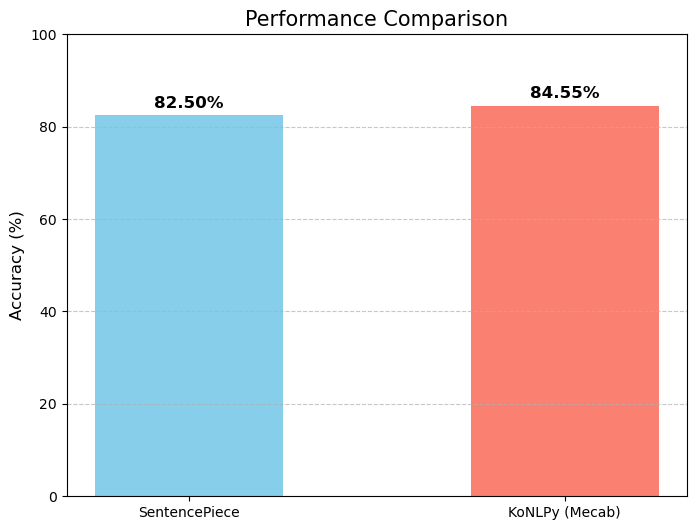

In [ ]:
import matplotlib.pyplot as plt

sp_acc = 82.50      # 예시: 아까 구한 SentencePiece 점수 (직접 수정)
mecab_acc = 84.55     # 방금 학습 끝나고 나온 Mecab 점수를 여기에 넣으세요!

# --- 그래프 그리기 ---
models = ['SentencePiece', 'KoNLPy (Mecab)']
scores = [sp_acc, mecab_acc]
colors = ['skyblue', 'salmon']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, scores, color=colors, width=0.5)

plt.title('Performance Comparison', fontsize=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()